# Abstract

This tutorial serves to provide a guide to understanding, accessing, and using the Dawn JWST Archive (DJA). Hosted by the Cosmic Dawn Center, the DJA enables astronomers worldwide to analyze galaxy formation, evolution, and the early universe through spectroscopy and imaging data from JWST. The tutorial is organized into five sections: (1) introduction to the DJA, explaining its purpose, scope, and types of data available (e.g., spectral and imaging data for studying galactic composition, distance, and structure); (2) database access, detailing navigation and retrieval of both updated and legacy versions; (3) usage instructions, including filtering data by parameters (e.g., redshift, signal-to-noise ratio, and emission lines) and interpreting charts, graphs, and images to draw meaningful conclusions; (4) data download and analysis, including Python templates for calculations, such as equivalent widths, UVJ plotting, and spectral feature analysis (e.g., 4000 Å break, Hα emission); and (5) spectral analysis of emission and absorption lines, illustrating how to interpret features like Hα, Lyman-α, OIII, and the 4000 Å break to study star formation, metallicity, and galaxy age. By the end of this tutorial, users should be able to access and use data from the DJA to answer questions about galaxies and the universe.


In [ ]:
# Setup: The Libraries
# This code installs the necessary libraries if not already available, clones a github repository being used to hold
# example galaxies, and imports what we will be using as data analysis tools.
# Note: Do not change this code.
!pip install astropy matplotlib numpy

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simps
from astropy.io import fits

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/
!git clone https://github.com/h-roundcount/DJA-Tutorial-Example-Galaxies.git


Mounted at /content/drive
/content/drive/MyDrive
fatal: destination path 'DJA-Tutorial-Example-Galaxies' already exists and is not an empty directory.


# Section 1: What is the Dawn JWST Archive?

The DAWN JWST Archive (DJA) is a tool for astronomers studying galaxies through data from the James Webb Space Telescope (JWST). Created by the Cosmic Dawn Center, the archive provides a space for publicly available galaxy gata, making data analysis more accessible for astronomers all over the world. According to the Cosmic Dawn Center, “The DAWN JWST Archive (DJA) is a repository of public JWST galaxy data [...] released for use by anyone.”

The DAWN JWST Archive is, for example, helpful for astronomers looking to analyze data for the purpose of answering questions about galaxy formation and evolution. Therefore, the archive is popular for people attempting to investigate the early universe, as JWST can observe galaxies at great distances.

The DJA contains various types of data, including spectroscopy and imaging data from JWST’s Near Infrared Spectrograph (NIRSpec) and Near Infrared Camera (NIRCam). This sort of information is used to study the emission of light from far-away galaxies, which can provide information about galactic composition, distance, and structure. Because of the large amount of data in the archive, astronomers can use it to learn this sort of information about galaxies across time.


# Section 2: How to Access the Database

To access the DAWN JWST Archive, use [this](https://s3.amazonaws.com/msaexp-nirspec/extractions/nirspec_graded_v2.html) link.

Alternatively, use [this](https://dawn-cph.github.io/dja/) link to access the website which hosts the database, and then locate the database from there. At this time, there is no tab built into the website to reach the most updated database version, but a less updated version is available by following these steps:



*   Open the side menu by clicking the three horizontal bars at the top of the page.
*   Select ‘Spectroscopy’ from the dropdown menu. Then choose ‘NIRSPEC SPECTRA.’
*   In the bullet point list that appears, click on the first link: nirspec_graded.html
*   This will direct you to an older version of the archive; however, the newer version should be used when possible, as more data is available there.


# Section 3: How to Use the Database

### Part 1: Filtering Ranges Box & Sorting Data

The DJA allows users to apply various filters and sorting mechanisms to refine the search. Each field corresponds to important characteristics of the galaxies observed. Here is a breakdown of the key filtering options:


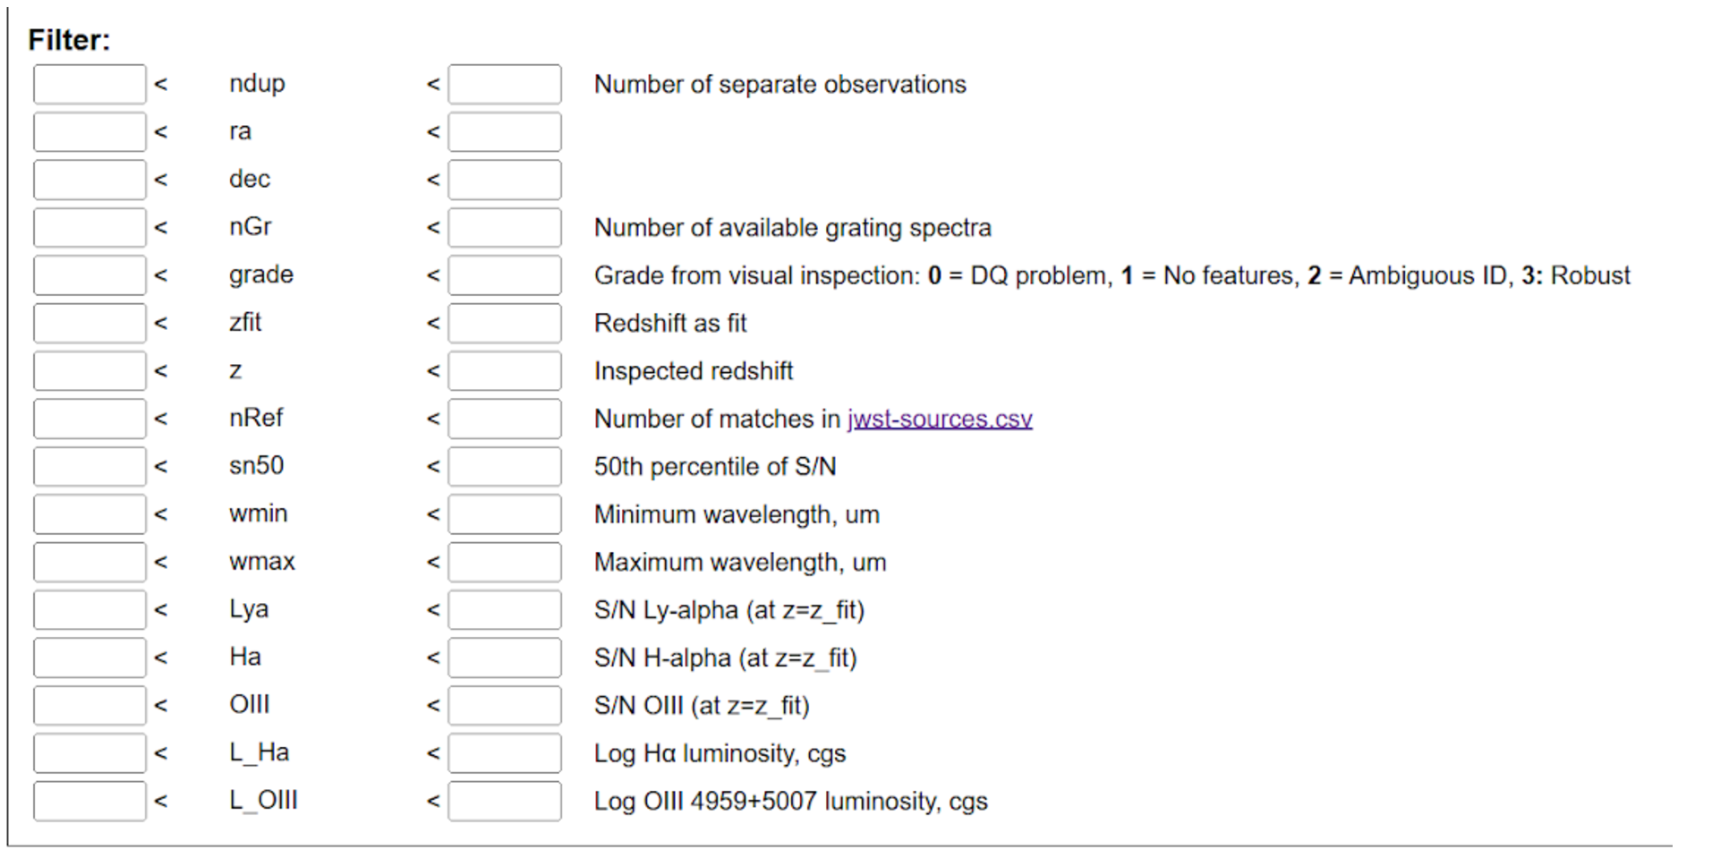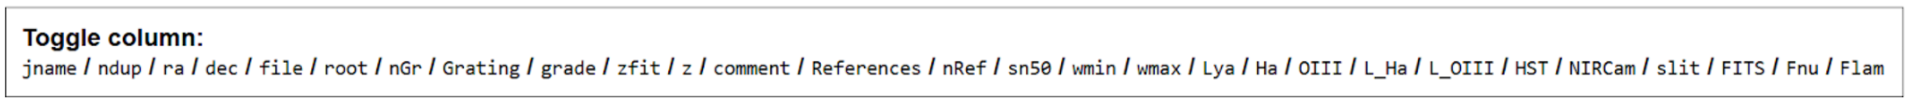

<table border="1" style="width: 100%; word-wrap: break-word; table-layout: fixed;">
  <tr>
    <th>Term</th>
    <th>Definition</th>
  </tr>
  <tr>
    <td>RA (Right Ascension)</td>
    <td>The east–west coordinate of a celestial body measured along the celestial equator. This functions basically as the “longitude” for celestial objects so that they are easier to locate in the sky.</td>
  </tr>
  <tr>
    <td>Dec (Declination)</td>
    <td>The angular distance of the galaxy from the celestial equator. This functions as the “latitude” in the sky and tells you how far north or south an object is.</td>
  </tr>
  <tr>
    <td>Grade</td>
    <td>The quality level of the data, with a higher grade representing a better quality. In general, filtering for only higher grade values leads to data with fewer errors and smaller uncertainties.</td>
  </tr>
  <tr>
    <td>zfit</td>
    <td>The redshift fit, showing how much the universe has expanded since the light from the galaxy was emitted. This can help refine the distance we estimate to be between us and the galaxy.</td>
  </tr>
  <tr>
    <td>z</td>
    <td>The redshift itself, which is extremely important in many different calculations, such as for age, the speed at which a body moves away from us, or distance.</td>
  </tr>
  <tr>
    <td>nRef</td>
    <td>The number of reference sources used for the spectral fit. A higher number is generally better because it can mean there is a more accurate fit.</td>
  </tr>
  <tr>
    <td>sn50</td>
    <td>The signal-to-noise ratio. This means it is a measurement of the strength of the signal from the galaxy compared to the background noise. Higher values indicate clearer data.</td>
  </tr>
  <tr>
    <td>wmin</td>
    <td>The minimum wavelength covered in the spectrum.</td>
  </tr>
  <tr>
    <td>wmax</td>
    <td>The maximum wavelength covered in the spectrum.</td>
  </tr>
  <tr>
    <td>Lya (Lyman-alpha)</td>
    <td>An emission line that has to do with hydrogen atoms. It is useful for studying distant galaxies and the early universe because hydrogen is abundant, and this line is often one of the strongest features in the spectra of young, star-forming galaxies.</td>
  </tr>
  <tr>
    <td>Ha (H-alpha)</td>
    <td>An emission line that has to do with hydrogen again. This one is commonly used to analyze and trace star formation because it is produced in parts of space where new stars are being born. [How is this different from Lya?]</td>
  </tr>
  <tr>
    <td>OIII (Oxygen-III)</td>
    <td>This emission line has to do with doubly ionized oxygen. It is often helpful when studying the metallicity of galaxies and can show that there is an active galactic nuclei (AGN) or a region where star formation is more intense.</td>
  </tr>
  <tr>
    <td>File</td>
    <td>The file name.</td>
  </tr>
  <tr>
    <td>Root</td>
    <td>The file’s root directory.</td>
  </tr>
  <tr>
    <td>Comments & References</td>
    <td>Notes about the dataset.</td>
  </tr>
  <tr>
    <td>Grating</td>
    <td>The type of grating used for the spectroscopic observation. A grating is a tool that splits light into different wavelengths, which lets us observe the spectrum of a galaxy. Different types of gratings can provide different levels of spectral resolution. Higher resolution means more detail in the spectrum.</td>
  </tr>
</table>


In addition to filtering based on the table above, you can filter how many entries appear per page and search for specific data entries.
To control how many entries appear per page, use the dropdown located near the search bar (between the filtering box and the data table itself). Select how many you want to see per page.
Secondly, if you have the information for a galaxy type or even for one specific file, you can use the search bar to find what you are looking for. It will search all fields of the data, so if you enter a file name, for example, it will show you only sources which contain that file name. However, if you just enter, for example, “1.7” with the intent of finding a galaxy with z = 1.7, any sources which have 1.7 in any part of it (such as sn50, Ha, wmin, zfit, z, etc) will be included in the results, so you may benefit more from using the filter box above the search bar.


### Part 2: Interpreting Graphs/Charts/Images

The DJA also provides a few types of graphs, charts, and images to help astronomers interpret the data and analyze trends. Here are the image and plot types, using glazebrook-v2_prism-clear_2565_14552.spec.fits for our example plots:

<table border="1">
  <tr>
    <th>Term</th>
    <th>Definition</th>
    <th>Example Photo</th>
  </tr>
  <tr>
    <td>HST</td>
    <td>Images from the Hubble Space Telescope. Complement JWST’s infrared data by providing a broader view of galaxies across multiple wavelengths.</td>
    <td><img src="https://grizli-cutout.herokuapp.com/thumb?size=1&scl=6.0&asinh=True&filters=f814w%2Cf125w%2Cf160w&rgb_scl=1.2%2C1.0%2C1.01&pl=2&coord=34.29375489590506%20-5.226993553368857" alt="Example HST image" width="150"></td>
  </tr>
  <tr>
    <td>NIRCam</td>
    <td>Images from the Near Infrared Camera (NIRCam). Takes infrared images, which is helpful for observing through dust and getting data for faint, early galaxies.</td>
    <td><img src="https://grizli-cutout.herokuapp.com/thumb?size=1&scl=4.0&asinh=True&filters=f115w-clear%2Cf277w-clear%2Cf444w-clear&rgb_scl=1.5%2C0.74%2C1.3&pl=2&coord=34.293755%20-5.226994" alt="Example NIRCam image" width="150"></td>
  </tr>
  <tr>
    <td>Slit</td>
    <td>Images from the NIRSpec slit. Provide spectra of specific regions within galaxies. Helpful for investigating chemical composition and velocities.</td>
    <td><img src="https://grizli-cutout.herokuapp.com/thumb?size=1&scl=4.0&invert=True&filters=f444w-clear&rgb_scl=1.5%2C0.74%2C1.3&pl=2&coord=34.293755%20-5.226994&nirspec=True&dpi_scale=6&nrs_lw=0.5&metafile=jw02565200001&nrs_alpha=0.8" alt="Example Slit image" width="150"></td>
  </tr>
  <tr>
    <td>Fnu</td>
    <td>Flux density per unit frequency.</td>
    <td><img src="https://s3.amazonaws.com/msaexp-nirspec/extractions/glazebrook-v2/glazebrook-v2_prism-clear_2565_14552.fnu.png" alt="Example Fnu graph" width="150"></td>
  </tr>
  <tr>
    <td>Flam</td>
    <td>Flux density per unit wavelength. For pinpointing absorption/emission lines and other important characteristics of a galaxy.</td>
    <td><img src="https://s3.amazonaws.com/msaexp-nirspec/extractions/glazebrook-v2/glazebrook-v2_prism-clear_2565_14552.flam.png" alt="Example Flam graph" width="150"></td>
  </tr>
</table>


All of these items are extremely helpful in terms of analyzing galaxies. For example, the 'slit' isolates a narrow slice of a galaxy's light, enabling the measurement of its spectrum to analyze properties like composition, velocity, and redshift. For compact quiescent galaxies, the slit often covers the entire galaxy, which means that all emitted light is often captured.

Using this "slice" of the galaxy, we can measure information about what wavelengths are being emitted or absorbed by the galaxy, which we'll learn more about in the next section. For example, one of the features the slit allows us to see is the Lyman break. This feature, caused by hydrogen absorption at specific wavelengths, helps calculate a galaxy’s redshift. This is because astronomers know what wavelength the Lyman break is supposed to be at, and we know what it looks like on a wave v. flux continuum like the ones below. Therefore, it is possible to "shift" the continuums so that the Lyman break in our galaxy lines up with the location we know it is supposed to have.

Here is an example of a continuum of wavelength plotted against flux. Various important "features" which are discoverable through use of the slit are highlighted and labelled, namely the Balmer break and spikes for H-alpha, [O III], and [S III]. More about these will be explained in the next section, but for now just know that large spikes in these locations are rare for "quiescent" (not star-forming) galaxies, meaning this one is either star-forming or has an Active Galactic Nuclei (AGN) messing with the data. In this case, this galaxy is in fact quiescent based on other analyses, so the answer is that this galaxy likely has a supermassive black hole powering an AGN.

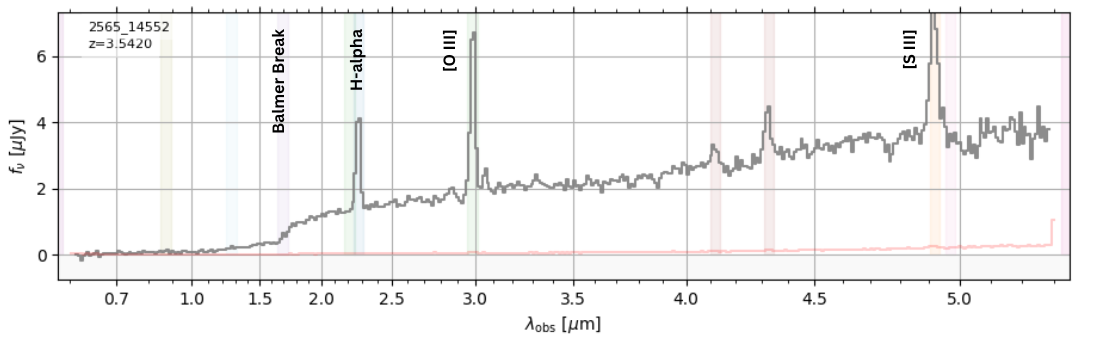

# Section Four: Downloading And Analyzing Data

Are you finished learning the context of the DJA? Then you might be ready to download some files and get started in your own analysis! Read on to find out how to do this on your own.

To download: In the table of data in the DJA, scroll to the far right until you see the FITS column. In this column, there are links to the .fits files, and when you click it, it will automatically download the files to your computer.

To access the files, use python scripts to read and plot the data. (For help using python, see [these tutorials](https://www.astrowhit.com/astronomy-research-tutorial-repository).)

If there's a specific plotter or function you want to use, upload your file to Google Colab, find the file path input line that will be present directly after the function you want to use, and copy and paste your file path, replacing the old one.

If you get an error about no directory being found, then the file has been uploaded incorrectly.

For now, the code will be set up to analyze example galaxies from the github repository. The data from these galaxies, as taken from the DJA, is given in a table in the appendix, with the relevant redshifts included. Be sure to edit the redshifts for functions where you are using different galaxies; otherwise, the data will be incorrect.


In [ ]:
#Don't change this code; it is simply setting up the example galaxies for you.

repo_path = '/content/drive/MyDrive/DJA-Tutorial-Example-Galaxies'
data_path = os.path.join(repo_path, 'data')
example_files = ['/content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/gds-barrufet-s67-v2_prism-clear_2198_6620.spec (1).fits', '/content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/gds-barrufet-s67-v2_prism-clear_2198_8290.spec (2).fits', "/content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/gds-barrufet-s67-v2_prism-clear_2198_8777.spec (2).fits",
                  "/content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/glazebrook-v2_prism-clear_2565_12629.spec (1).fits", "/content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/glazebrook-v2_prism-clear_2565_13079.spec.fits",
                  "/content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/glazebrook-v2_prism-clear_2565_14552.spec (2) (1).fits",
                  "/content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/glazebrook-v2_prism-clear_2565_4232.spec.fits"]
example_redshifts = [4.3563, 4.6563, 3.4713, 3.1962, 3.1979, 3.542, 3.6921]

# Section Five: More Analysis (Emission/Absorption)

One common way to analyze a galaxy is by looking at the emission or absorption lines in its spectroscopy, which is the powerhouse behind all of the data analysis I've mentioned so far--once you understand how to use spectroscopy, galaxies become much less mysterious!

According to the [Space Science Telescope Institute](https://webbtelescope.org/contents/articles/spectroscopy-101--introduction#:~:text=Spectroscopy%20is%20used%20to%20figure,very%20specific%20and%20predictable%20ways.), spectroscopy is a “scientific method of studying objects and materials based on detailed patterns of colors (wavelengths).” From this, astronomers can then figure out chemical composition, temperature, density, and velocity of an object (in our case, a galaxy). Chemical composition, for example, can be deduced due to the fact that each element will interact with different light wavelengths in different ways; by looking at a continuum of wavelengths, we see spikes or dips depending on which elements are present.

These “spikes” and “dips” are called emission and absorption lines, respectively. They're what I was labelling in that earlier continuum!

When light passes through a lot of molecules, for example starlight through a galaxy, some of the light is transmitted through the galaxy’s gas, but some of it is absorbed and does not make it through. Which light makes it through depends on its wavelength, and it is the various elements in the gas that determine which wavelengths will be blocked. Therefore, if a galaxy is absorbing a specific wavelength of light, astronomers can conclude that the corresponding element must be present in the galaxy. These absorption lines show up as dark marks on a color continuum or dips on a graphical representation of wavelength v. brightness, as seen below.

If the atoms in a cloud of gas become excited by starlight, the gas itself may begin to emit light. An emission spectrum charts the wavelengths of light that are being received from that galaxy; the spectrum in this case is mostly dark with just a few colored lines representing the wavelengths received from that galaxy. On a wavelength v. brightness graph, the emission lines show up as “spikes.”


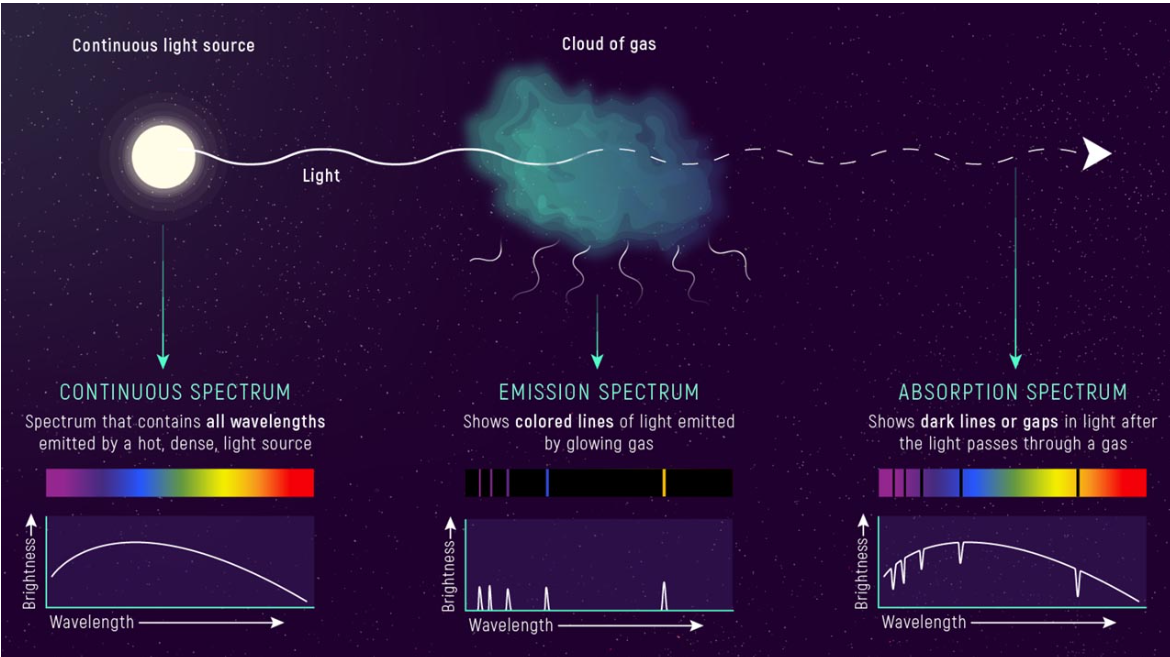

Caption: NASA, ESA, Leah Hustak (STScI)

In general, the Flam column on the DJA can be used to analyze spectroscopy in this way. To do this, it is worth noting that the continuums in the DJA generally have units of 10^(-20) ergs^(-1) cm^(-2) Å ^(-1) and μm. For most of the plotters linked above as well as most analysis in general, these would not be the standard units; instead, converting to μJy and Å, respectively, is strongly recommended.

Here are some of the most common spectral lines to look for:

<table border="1">
  <tr>
    <th>Type</th>
    <th>Line</th>
    <th>Wavelength (Å)</th>
    <th>Description</th>
  </tr>
  <tr>
    <td rowspan="3">Emission Lines</td>
    <td>Hydrogen Balmer series - H𝛼</td>
    <td>6563</td>
    <td>Indicate star formation or a supermassive black hole.</td>
  </tr>
  <tr>
    <td>Hydrogen Balmer series - H𝛽</td>
    <td>4861</td>
    <td>Indicate star formation or a supermassive black hole.</td>
  </tr>
  <tr>
    <td>Hydrogen Balmer series - H𝛾</td>
    <td>4340</td>
    <td>Indicate star formation or a supermassive black hole.</td>
  </tr>
  <tr>
    <td>Emission Lines</td>
    <td>[O III]</td>
    <td>5007</td>
    <td>Indicate star formation or a supermassive black hole.</td>
  </tr>
  <tr>
    <td>Emission Lines</td>
    <td>Lyman-α</td>
    <td>1216</td>
    <td>Indicate high-redshift galaxies.</td>
  </tr>
  <tr>
    <td>Absorption Lines</td>
    <td>Calcium H and K</td>
    <td>3968 & 3934</td>
    <td>Indicate low-temperature stars.</td>
  </tr>
  <tr>
    <td>Absorption Lines</td>
    <td>Hydrogen Balmer Lines</td>
    <td>N/A</td>
    <td>Common as absorption lines in A-type stars.</td>
  </tr>
</table>




You can run this code on a variety of functions to see the spectrums sorted by redshift, with several significant wavelengths labeled where you might see emission or absorption features. Replace the file paths with your own, use the corresponding redshift values from the DJA, and see what features your galaxies have!

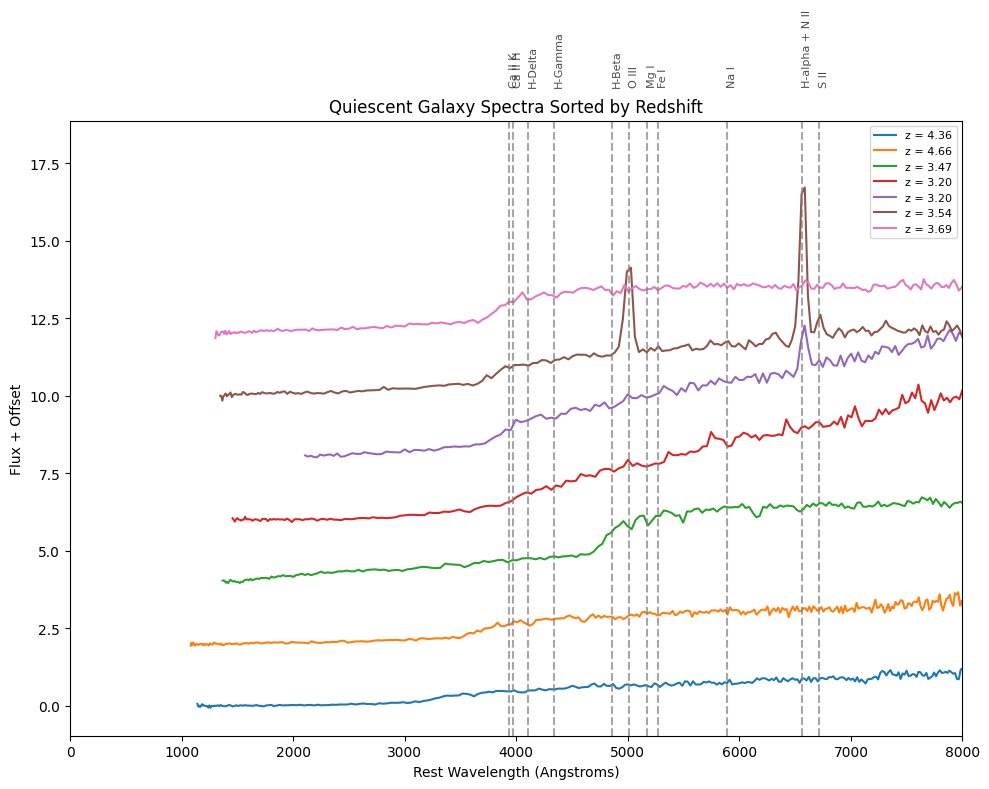

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

prominent_features = {
    "Ca II H": 3968,
    "Ca II K": 3934,
    "H-Delta": 4102,
    "H-Gamma": 4340,
    "H-Beta": 4861,
    "O III": 5007,
    "Mg I": 5175,
    "Fe I": 5270,
    "Na I": 5893,
    "H-alpha + N II": 6563,
    "S II": 6716,
}

def process_fits_file(fits_file, redshift):
    with fits.open(fits_file) as hdul:
        data = hdul[1].data
        wavelength = data['wave'] * 1e4  # Convert micrometers to Angstroms - DO NOT EDIT THIS LINE
        flux = data['flux']

    # Here, we convert to rest frame to standardize our spectrums.
    lambda_rest = wavelength / (1 + redshift)
    return lambda_rest, flux

def plot_quiescent_spectra(fits_files, redshifts):
    """
    Plots quiescent galaxy spectra from all of the FITS files you add to the list (fits_files),
    sorted by redshifts which you add to the other list (redshifts). Make sure to keep the redshifts
    in the same order that your files are so they correspond correctly.
    """
    plt.figure(figsize=(10, 8))

    #Here, we plot the spectrums themselves; wavelength versus flux.
    #If the lines are too close together, change offset to be larger.
    for i, (fits_file, z) in enumerate(zip(fits_files, redshifts)):
        offset = 2 #This is where you can change the offset value if you need.
        lambda_rest, flux = process_fits_file(fits_file, z)
        offset = i * offset
        plt.plot(lambda_rest, flux + offset, label=f"z = {z:.2f}")

    # Here we add vertical lines at the locations of all of the significant wavelengths.
    for feature, wavelength in prominent_features.items():
        plt.axvline(x=wavelength, color='gray', linestyle='--', alpha=0.7)
        plt.text(wavelength, 2.85 * len(fits_files), feature, rotation=90, verticalalignment='bottom', fontsize=8, alpha=0.7)

    # Plot everything.
    plt.xlabel("Rest Wavelength (Angstroms)")
    plt.xlim(0, 8000)
    plt.ylabel("Flux + Offset")
    plt.title("Quiescent Galaxy Spectra Sorted by Redshift")
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# Run the code!
fits_files = example_files #replace this with a list of your own files, or edit the example_files list which appeared under the "Downloaded Data" section.
redshifts = example_redshifts #replace this with a list of your own values which correspond with the files you downloaded; this information is the z-spec column on the DJA.
plot_quiescent_spectra(fits_files, redshifts)


**Finally, one last important note on the existence of the 4000 Å break:** The “4000 Å break” is a sharp dip in the spectrum at about 4000 Å caused by the accumulation of lots of different metals’ absorption lines from cool stars. It can be used to indicate the age of the stars in a galaxy; a stronger break means that there are probably a lot of older stars (elliptical galaxies, passive galaxies), while a weak break means that most of the stars are probably younger and hotter. If the break is weak, then it is probably a star-forming galaxy. If not, it may be quiescent.

**D4000[Hα] Plotter:**

This plots a comparison between the D4000 break versus Hα emission. A strong D4000 break combined with a weak Hα emission generally signals that the galaxy is no longer star-forming, as the D4000 indicates age and the Hα emission is associated with star formation.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

def convert_to_angstroms(wavelength_micrometers):
    return wavelength_micrometers * 1e4

def calculate_d4000(wavelength, flux, redshift):
    """
    Calculate the D4000 index.
    """
    # First, we convert to rest frame.
    rest_wavelength = wavelength / (1 + redshift)

    # Here we create wavelength ranges for D4000 calculation in Angstroms so we do not have to parse ALL of the data
    blue_range = (3750, 3950)
    red_range = (4050, 4250)
    blue_mask = (rest_wavelength >= blue_range[0]) & (rest_wavelength <= blue_range[1])
    red_mask = (rest_wavelength >= red_range[0]) & (rest_wavelength <= red_range[1])

    # Calculate mean fluxes in each range
    if np.any(blue_mask) and np.any(red_mask):
        mean_flux_blue = np.mean(flux[blue_mask])
        mean_flux_red = np.mean(flux[red_mask])
        return mean_flux_red / mean_flux_blue
    else:
        raise ValueError("No valid indices found for D4000 calculation.")

def calculate_ew_hdelta(wavelength, flux, redshift):
    """
    Calculate the equivalent width of Hδ.

    This function measures the width of the absorption or emission feature in the spectrum
    relative to the surrounding continuum. It is a common way to quantify the
    strength of a spectral line.
    """
    # First, we convert to rest frame (Are you noticing a pattern with this?)
    rest_wavelength = wavelength / (1 + redshift)

    # Create our ranges.
    hdelta_range = (4083, 4122)
    continuum_range = (4041, 4079)


    hdelta_mask = (rest_wavelength >= hdelta_range[0]) & (rest_wavelength <= hdelta_range[1])
    continuum_mask = (rest_wavelength >= continuum_range[0]) & (rest_wavelength <= continuum_range[1])



    if np.any(hdelta_mask) and np.any(continuum_mask):
        # Calculate continuum flux and Hδ flux
        continuum_flux = np.mean(flux[continuum_mask])
        hdelta_flux = np.sum(np.abs(flux[hdelta_mask] - continuum_flux))
        hdelta_width = np.ptp(rest_wavelength[hdelta_mask])  # Peak-to-peak wavelength range
        print("Continuum Flux:", continuum_flux)
        print("Hδ Flux:", hdelta_flux)
        return hdelta_flux / continuum_flux * hdelta_width
    else:
        raise ValueError("No valid indices found for Hδ equivalent width calculation.")


def process_fits_file(fits_file, redshift=0):
    """
    This takes the files you have and makes them usable. It also makes our
    flux and wavelength lists!
    """
    # Open the FITS file and extract wavelength and flux
    with fits.open(fits_file) as hdul:
        data = hdul[1].data
        wavelength = data['wave']
        flux = data['flux']

    # Convert units to Angstroms
    wavelength_angstroms = convert_to_angstroms(wavelength)

    # Calculate D4000 index
    d4000 = calculate_d4000(wavelength_angstroms, flux, redshift)

    # Calculate Hδ equivalent width
    ew_hdelta = calculate_ew_hdelta(wavelength_angstroms, flux, redshift)

    return d4000, ew_hdelta

def plot_d4000_vs_ew(fits_files, redshifts):
    """
    Plots D4000 index against Hδ equivalent width for all of your different FITS files.
    """
    # Some error catching. If this error runs, it means you probably accidentally
    # added a copy of a galaxy or redshift, or accidentally forgot to include one.
    if len(fits_files) != len(redshifts):
        raise ValueError("The number of FITS files and redshifts must match.")

    d4000_values = []
    ew_hdelta_values = []

    for fits_file, redshift in zip(fits_files, redshifts):
        try:
            print(f"Processing {fits_file} with redshift {redshift}...")
            d4000, ew_hdelta = process_fits_file(fits_file, redshift)
            d4000_values.append(d4000)
            ew_hdelta_values.append(ew_hdelta)
        except ValueError as e:
            print(f"Skipping file {fits_file}: {e}")
        except Exception as e:
            print(f"Unexpected error with file {fits_file}: {e}")

    # Plot!
    plt.figure(figsize=(8, 6))
    plt.scatter(d4000_values, ew_hdelta_values, color='blue', edgecolor='k')
    plt.ylim(bottom=-0.1, top=2)
    plt.xlabel('D4000 Index', fontsize=14)
    plt.ylabel('EW(Hδ) [Angstroms]', fontsize=14)
    plt.title('D4000 vs. EW(Hδ)', fontsize=16)
    plt.grid(True)
    plt.show()

Processing /content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/gds-barrufet-s67-v2_prism-clear_2198_6620.spec (1).fits with redshift 4.3563...
Continuum Flux: 0.43818592038745285
Hδ Flux: 0.06234870141489812
Processing /content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/gds-barrufet-s67-v2_prism-clear_2198_8290.spec (2).fits with redshift 4.6563...
Continuum Flux: 0.6925869113512175
Hδ Flux: 0.049992491610579504
Processing /content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/gds-barrufet-s67-v2_prism-clear_2198_8777.spec (2).fits with redshift 3.4713...
Continuum Flux: 0.753256410280987
Hδ Flux: 0.012160313215935359
Processing /content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/glazebrook-v2_prism-clear_2565_12629.spec (1).fits with redshift 3.1962...
Continuum Flux: 0.8120541784485765
Hδ Flux: 0.07229556371914792
Processing /content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/glazebrook-v2_prism-clear_2565_13079.spec.fits with redshift 3.1979...
Continuum Flux: 1.1498789339888027
H

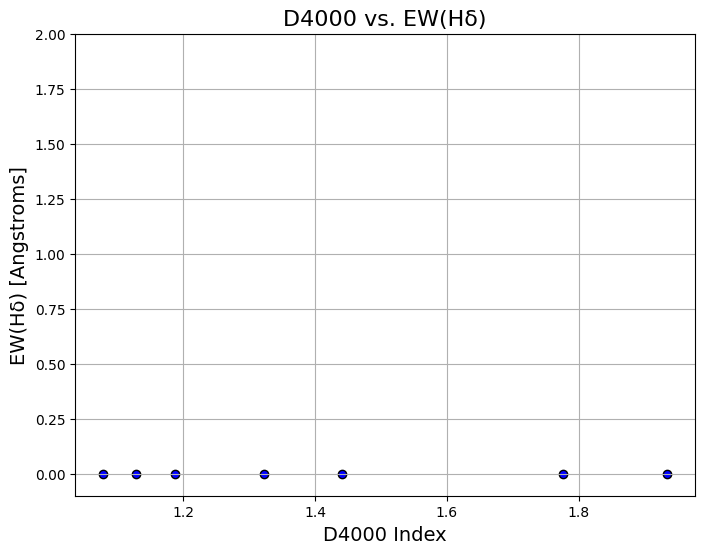

In [ ]:
#Run that last huge section of code!

fits_files = example_files
redshifts = example_redshifts
plot_d4000_vs_ew(fits_files, redshifts)


As you can see, the EW[H-delta] values here are all extremely low, while the D4000 index values are more spread out. In general, a low EW[H-delta] and a high D4000 index indicates a quiescent galaxy, while low values for both mean star forming, and large EW[H-delta] could mean it's a post-starburst galaxy, which is an intermediate phase between star-forming and quiescent. These galaxies have experienced a sudden, intense burst of star formation, often triggered by events such as galaxy mergers.

# Conclusion

The Dawn JWST Archive is incredibly helpful to astronomers by providing data for a large quantity of galaxies to researchers everywhere; from this data, information about a galaxy’s age, composition, star formation, etc, becomes easily accessible.

Knowing information about a galaxy’s age and star formation status can help contribute toward answering big questions about the universe, such as by creating a picture of what galactic evolution might look like or informing us about the early universe.

For help using the archive, the Cosmic Dawn Center recommends the [Discussions](https://github.com/dawn-cph/dja/discussions) or [Issues](https://github.com/dawn-cph/dja/issues) functionality on the [repository](https://github.com/dawn-cph/dja) page.

# Works Cited

“About the DJA.” *The Dawn JWST Archive*, dawn-cph.github.io/dja/about/summary/.

Dawn-CPH. “Dawn-CPH DJA Repository.” *GitHub*, github.com/dawn-cph/dja.

Hustak, Leah. "Types of Spectra: Continuous, Emission, and Absorption," *Webb Space Telescope*, 2 July 2021, webbtelescope.org/contents/media/images/01F8GF8DK2PRY4FP9DA2XPQC8S.

"Spectroscopy 101 – Introduction," *Webb Space Telescope*, 7 July 2022, webbtelescope.org/contents/articles/spectroscopy-101--introduction.

# Appendix



### The Data (High-Grade Quiescent Galaxy Data from the DJA)

<table border="1" style="width: 100%; text-align: left; border-collapse: collapse;">
  <thead>
    <tr>
      <th>JWST Program ID</th>
      <th>RA</th>
      <th>Dec</th>
      <th>zspec</th>
      <th>Author</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>2198</td>
      <td>53.081879</td>
      <td>-27.828799</td>
      <td>4.3563</td>
      <td>Barrufet+24</td>
    </tr>
    <tr>
      <td>2198</td>
      <td>53.108204</td>
      <td>-27.825188</td>
      <td>4.6563</td>
      <td>Barrufet+24</td>
    </tr>
    <tr>
      <td>2198</td>
      <td>53.078727</td>
      <td>-27.839608</td>
      <td>3.4713</td>
      <td>Barrufet+24</td>
    </tr>
    <tr>
      <td>2565</td>
      <td>34.255885</td>
      <td>-5.233871</td>
      <td>3.1962</td>
      <td>Schreiber+18</td>
    </tr>
    <tr>
      <td>2565</td>
      <td>34.258906</td>
      <td>-5.232347</td>
      <td>3.1979</td>
      <td>Glazebrook+24</td>
    </tr>
    <tr>
      <td>2565</td>
      <td>34.290455</td>
      <td>-5.262115</td>
      <td>3.6921</td>
      <td>Schreiber+18</td>
    </tr>
    <tr>
      <td>2565</td>
      <td>34.293755</td>
      <td>-5.226994</td>
      <td>3.543</td>
      <td>Schreiber+18</td>
    </tr>
  </tbody>
</table>


### Rest Frame Color Color Plotter

One other useful function for analyzing galaxies is the rest frame color color diagram plotter.

This code creates a plot that shows the color of the galaxy in two different wavelength bands, which helps to sort galaxies based off star formation. Quiescent galaxies, for example, are generally more red compared to star-forming galaxies.

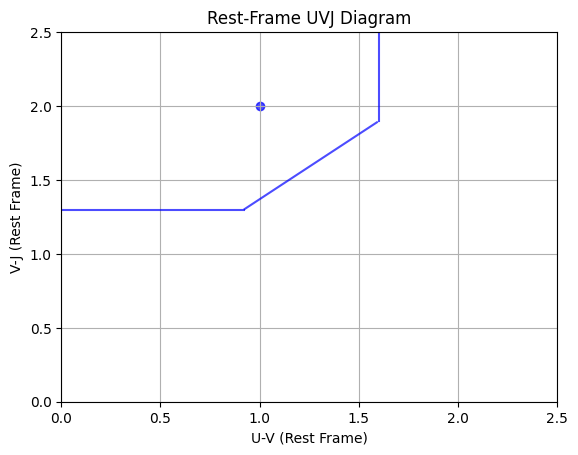

In [ ]:
# This is going to require some outside research from you. The DJA doesn't have a convenient way of extracting color information yet.
# Therefore, you are required to provide the redshift and magnitudes as input parameters yourself.
# You can do this by finding papers which discuss the galaxies you're analyzing; for example, by using the NASA ADS: https://ui.adsabs.harvard.edu/
# The script will only use the .fits file for wavelength extraction.

def rest_frame_color_color_plot(fits_file, redshift, u_mag, v_mag, j_mag):
    """
    Creates a rest-frame UVJ diagram (U-V vs. V-J). You will need to find literature
    that includes the u,v, and j values you need, because they are not avaialable on the DJA.
    """
    # Open the .fits file and extract wavelength
    with fits.open(fits_file) as hdul:
        data = hdul[1].data
        wavelength = data['wave']

    # Conert to rest frame
    def correct_for_redshift(mag, z):
        return mag - 2.5 * np.log10(1 + z)

    u_rest = correct_for_redshift(u_mag, redshift)
    v_rest = correct_for_redshift(v_mag, redshift)
    j_rest = correct_for_redshift(j_mag, redshift)

    v_j_color = np.linspace(0.5, 2, 100)  # V-J color range

    u_v_color = 0.88 * v_j_color + 0.49  # Diagonal line equation
    u_v_horizontal = 1.3  # Horizontal line: U-V = 1.3
    v_j_vertical = 1.6    # Vertical line: V-J = 1.6
    v_j_intersection = (1.3 - 0.49) / 0.88
    u_v_intersection = 0.88 * 1.6 + 0.49
    plt.plot(v_j_color[(v_j_color >= v_j_intersection) & (v_j_color <= 1.6)],
            u_v_color[(v_j_color >= v_j_intersection) & (v_j_color <= 1.6)], c='blue', label=r'Diagonal Segment', alpha=0.7)
    plt.plot(np.linspace(0, v_j_intersection, 10), np.ones(10) * u_v_horizontal, c='blue', label=r'Horizontal Segment', alpha=0.7)
    plt.plot(np.ones(10) * 1.6, np.linspace(u_v_intersection, 3, 10), c='blue', label=r'Vertical Segment', alpha=0.7)

    # Plot it!
    plt.scatter(u_rest - v_rest, v_rest - j_rest, c='blue', alpha=0.7)
    plt.xlabel('U-V (Rest Frame)')
    plt.ylabel('V-J (Rest Frame)')
    plt.xlim(0, 2.5)  # Set x-axis range from 0 to 2 (adjust as needed)
    plt.ylim(0, 2.5)
    plt.title('Rest-Frame UVJ Diagram')
    plt.grid()
    plt.show()

# Example (replace the .fits file with your own) - not real UVJ values:
rest_frame_color_color_plot('/content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/glazebrook-v2_prism-clear_2565_14552.spec (3).fits', redshift=3.542, u_mag=24, v_mag=23, j_mag=21.0)

#The section in the top left is generally made up of quiescent galaxies.


Example use of this program creates output like this: 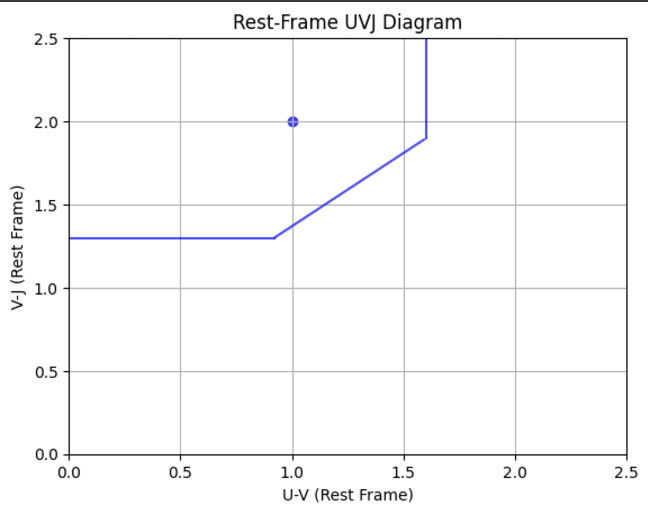

Because the plot has the "dot" (representing this galaxy) in the upper left corner within the blue bounds, this example galaxy would be quiescent. Try it with your own .fits file to determine if yours is quiescent or star-forming.

### Get Column Names from FITS: A Troubleshooting Program

If you are getting errors in your code about how the terms you're using to parse the data are wrong, you can try running this program on your file to get the names of the columns. This is purely helpful in a troubleshooting sense if your FITS analyses programs are failing.

In [ ]:
def inspect_fits_file(fits_file):
    hdul = fits.open(fits_file)
    # Print the header information to see the available columns
    print(hdul[1].columns)

# Example usage:
inspect_fits_file(r"/content/drive/MyDrive/DJA-Tutorial-Example-Galaxies/glazebrook-v2_prism-clear_2565_14552.spec (3).fits")

ColDefs(
    name = 'wave'; format = 'D'; unit = 'um'
    name = 'flux'; format = 'D'; unit = 'uJy'
    name = 'err'; format = 'D'; unit = 'uJy'
)
